<a href="https://colab.research.google.com/github/annaizyurieva-stack/IDP-Project-Diabetics/blob/2-%D1%8D%D1%82%D0%B0%D0%BF/2_%D1%8D%D1%82%D0%B0%D0%BF_%D0%B0%D1%83%D0%B4%D0%B8%D1%82_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%98%D0%B7%D1%8E%D1%80%D1%8C%D0%B5%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Первичный аудит данных: Pima Indians Diabetes

**Датасет:** `diabetes_dataset.csv` — 768 пациенток, 8 клинических признаков и целевая метка `Outcome` (1 — диабет есть, 0 — нет).
Одна строка = одна пациентка.

**План аудита**
1. Общая статистика
2. Пропуски (в том числе скрытые) и их заполнение
3. Дубликаты
4. Константные признаки
5. Баланс классов
6. Распределения числовых признаков
7. Boxplot для приоритетных признаков, выбросы и аномалии
8. Профиль качества исходной таблицы
9. Выводы

Расшифровка значений из датасета и допустимые границы (словарь RULES в 7 пункте)

| Признак | Смысл | Тип | Правило допустимых значений |
|---|---|---|---|
| Pregnancies | Число беременностей | int | 0–20 |
| Glucose | Глюкоза плазмы, мг/дл | int | 40–500 |
| BloodPressure | Диастолическое давление, мм рт. ст. | int | 40–140 |
| SkinThickness | Толщина кожной складки, мм | int | 5–100 |
| Insulin | Инсулин сыворотки, мкЕД/мл | int | 10–900 |
| BMI | Индекс массы тела | float | 12–70 |
| DiabetesPedigreeFunction | Наследственная предрасположенность | float | > 0 |
| Age | Возраст, лет | int | 18–120 |
| Outcome | Диабет (цель) | int | 0 или 1 |

Границы выбраны как физиологически правдоподобные

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

TARGET = "Outcome"

## 0. Загрузка данных

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()          # загружаем датасет diabetes_dataset.csv
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    DATA_PATH = "diabetes_dataset.csv"  # локальный запуск

df_raw = pd.read_csv(DATA_PATH)         # исходник — не трогаем
df = df_raw.copy()                      # рабочая копия
print("Строк:", df_raw.shape[0], "| Столбцов:", df_raw.shape[1])
df_raw.head()

Saving diabetes_dataset.csv to diabetes_dataset.csv
Строк: 768 | Столбцов: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Общая статистика

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
stats = df_raw.describe().T
stats["median"] = df_raw.median()
stats["skew"] = df_raw.skew()
stats = stats[["count", "mean", "median", "std", "min", "25%", "75%", "max", "skew"]]
stats.round(2)

,count,mean,median,std,min,25%,75%,max,skew
Pregnancies,768.0,3.85,3.00,3.37,0.00,1.00,6.00,17.00,0.90
Glucose,768.0,120.89,117.00,31.97,0.00,99.00,140.25,199.00,0.17
BloodPressure,768.0,69.11,72.00,19.36,0.00,62.00,80.00,122.00,-1.84
SkinThickness,768.0,20.54,23.00,15.95,0.00,0.00,32.00,99.00,0.11
Insulin,768.0,79.80,30.50,115.24,0.00,0.00,127.25,846.00,2.27
BMI,768.0,31.99,32.00,7.88,0.00,27.30,36.60,67.10,-0.43
DiabetesPedigreeFunction,768.0,0.47,0.37,0.33,0.08,0.24,0.63,2.42,1.92
Age,768.0,33.24,29.00,11.76,21.00,24.00,41.00,81.00,1.13
Outcome,768.0,0.35,0.00,0.48,0.00,0.00,1.00,1.00,0.64


**Вывод:** Типы данных корректные (числа), формальных пропусков нет. Но в `describe()` видно подозрительное: минимум **0** у `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`. Для живого человека давление, ИМТ и глюкоза равны нулю быть не могут — это не измерения, а закодированные пропуски. Дальше проверим это отдельно.

## 2. Пропуски
### 2.1 Формальные пропуски (`NaN`)

In [5]:
nan_tbl = pd.DataFrame({"NaN": df_raw.isna().sum(), "доля, %": (df_raw.isna().mean() * 100).round(2)})
nan_tbl

,NaN,"доля, %"
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


### 2.2 Скрытые пропуски: нули
Ноль допустим в `Pregnancies` (нет беременностей) и `Outcome` (нет диабета). В остальных медицинских признаках ноль физиологически невозможен, поэтому трактуем его как пропуск.

In [6]:
ZERO_AS_NA = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zeros = pd.DataFrame({
    "нулей": (df_raw[ZERO_AS_NA] == 0).sum(),
    "доля, %": ((df_raw[ZERO_AS_NA] == 0).mean() * 100).round(1),
})
print("Нули в Pregnancies (допустимы):", (df_raw["Pregnancies"] == 0).sum())
zeros

Нули в Pregnancies (допустимы): 111


,нулей,"доля, %"
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


Строк с хотя бы одним скрытым пропуском: 376 (49.0%)
Строк, где пропущено 2+ признака:        234


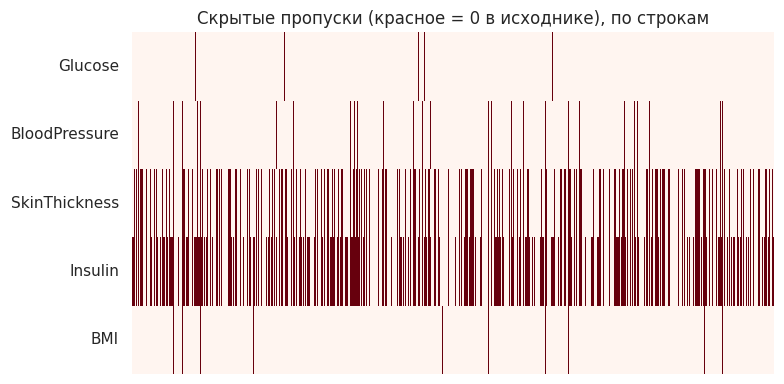

In [7]:
# Пересечение пропусков: сколько строк теряет несколько признаков сразу
miss_mask = (df_raw[ZERO_AS_NA] == 0)
print("Строк с хотя бы одним скрытым пропуском:", miss_mask.any(axis=1).sum(),
      f"({miss_mask.any(axis=1).mean()*100:.1f}%)")
print("Строк, где пропущено 2+ признака:       ", (miss_mask.sum(axis=1) >= 2).sum())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(miss_mask.T, cbar=False, cmap="Reds", yticklabels=ZERO_AS_NA, xticklabels=False, ax=ax)
ax.set_title("Скрытые пропуски (красное = 0 в исходнике), по строкам")
plt.tight_layout(); plt.show()

**Причина.** Отсутствующие измерения записаны нулями. Инсулин и толщина кожной складки пропущены у 48.7% и 29.6% пациенток, а хотя бы один пропуск есть у 49% строк, поэтому удалять строки нельзя — потеряем почти половину выборки.

### 2.3 Заполнение
Выбор способа: **медиана** (устойчива к выбросам, а у `Insulin` распределение сильно скошено) + **флаги пропуска** для двух самых «дырявых» признаков (`Insulin`, `SkinThickness`), чтобы сохранить информацию о том, что измерение отсутствовало.

In [8]:
df[ZERO_AS_NA] = df[ZERO_AS_NA].replace(0, np.nan)

for col in ["Insulin", "SkinThickness"]:
    df[f"{col}_was_missing"] = df[col].isna().astype(int)

medians = df[ZERO_AS_NA].median()
print("Медианы для заполнения:\n", medians.round(1).to_string())

df[ZERO_AS_NA] = df[ZERO_AS_NA].fillna(medians)
print("\nОсталось NaN:", int(df[ZERO_AS_NA].isna().sum().sum()))

Медианы для заполнения:
 Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.3

Осталось NaN: 0


## 3. Дубликаты

In [9]:
feature_cols = [c for c in df_raw.columns if c != TARGET]

full_dups   = df_raw.duplicated().sum()
feature_dup = df_raw.duplicated(subset=feature_cols).sum()   # одинаковые признаки (возможен конфликт метки)

print("Полных дубликатов строк:                 ", full_dups)
print("Дубликатов по признакам (без Outcome):   ", feature_dup)
print("Строк до:", len(df))

df = df.drop_duplicates().reset_index(drop=True)
print("Строк после drop_duplicates:", len(df))

Полных дубликатов строк:                  0
Дубликатов по признакам (без Outcome):    0
Строк до: 768
Строк после drop_duplicates: 768


**Вывод:** дубликатов нет, в том числе нет конфликтных пар «те же признаки — разная метка».

## 4. Константные признаки

In [10]:
const_tbl = pd.DataFrame({
    "уникальных": df_raw.nunique(),
    "std": df_raw.std().round(3),
    "доля самого частого значения, %": (df_raw.apply(lambda s: s.value_counts(normalize=True).iloc[0]) * 100).round(1),
    "самое частое значение": df_raw.apply(lambda s: s.value_counts().index[0]),
})
const_tbl["константа"] = const_tbl["уникальных"] == 1
const_tbl["квазиконстанта (>95%)"] = const_tbl["доля самого частого значения, %"] > 95
const_tbl

,уникальных,std,"доля самого частого значения, %",самое частое значение,константа,квазиконстанта (>95%)
Pregnancies,17,3.370,17.6,1.000,False,False
Glucose,136,31.973,2.2,99.000,False,False
BloodPressure,47,19.356,7.4,70.000,False,False
SkinThickness,51,15.952,29.6,0.000,False,False
Insulin,186,115.244,48.7,0.000,False,False
BMI,248,7.884,1.7,32.000,False,False
DiabetesPedigreeFunction,517,0.331,0.8,0.258,False,False
Age,52,11.760,9.4,22.000,False,False
Outcome,2,0.477,65.1,0.000,False,False


**Вывод:** константных и квазиконстантных признаков нет — удалять нечего. Важно: самое частое значение в `Insulin` и `SkinThickness` — это 0 (48.7% и 29.6% строк); это скрытые пропуски, а не реальные измерения. После заполнения медианой эти признаки тоже не константны (см. таблицу ниже).

In [11]:
print("После очистки: константных столбцов =", int((df.nunique() == 1).sum()))
(df[ZERO_AS_NA].apply(lambda s: s.value_counts(normalize=True).iloc[0]) * 100).round(1).rename("доля топ-значения после заполнения, %")

После очистки: константных столбцов = 0


,"доля топ-значения после заполнения, %"
Glucose,2.2
BloodPressure,10.3
SkinThickness,31.8
Insulin,49.2
BMI,1.8


## 5. Баланс классов

,пациенток,"доля, %"
0 — диабета нет,500,65.1
1 — диабет есть,268,34.9


Соотношение классов: 1.87 : 1
Accuracy модели «всем: диабета нет»: 65.1%
Recall класса «диабет есть» у такой модели: 0% (найдено 0 из 268 )


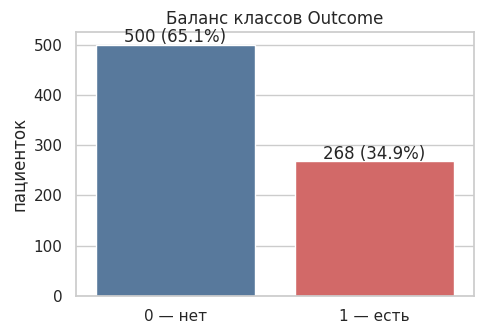

In [12]:
cls = df_raw[TARGET].value_counts().sort_index()
bal = pd.DataFrame({"пациенток": cls, "доля, %": (cls / cls.sum() * 100).round(1)})
bal.index = ["0 — диабета нет", "1 — диабет есть"]
display(bal)

ratio = cls.max() / cls.min()
print(f"Соотношение классов: {ratio:.2f} : 1")

# «Глупая» модель — всегда предсказывает мажоритарный класс
acc_dummy = cls.max() / cls.sum()
print(f"Accuracy модели «всем: диабета нет»: {acc_dummy:.1%}")
print("Recall класса «диабет есть» у такой модели: 0% (найдено 0 из", cls.min(), ")")

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=["0 — нет", "1 — есть"], y=cls.values, hue=["0", "1"], palette=["#4C78A8", "#E45756"], legend=False, ax=ax)
for i, v in enumerate(cls.values):
    ax.text(i, v + 5, f"{v} ({v/cls.sum():.1%})", ha="center")
ax.set_title("Баланс классов Outcome"); ax.set_ylabel("пациенток")
plt.tight_layout(); plt.show()

**Оценка.** Дисбаланс **умеренный** (≈ 65/35, ~1.9:1), не критичный как 95/5. Но accuracy всё равно вводит в заблуждение: константная модель получит ≈65% и найдёт 0 больных.

## 6. Распределения числовых признаков
Строим по **очищенной** таблице (после замены нулей на медиану) и сравниваем с исходной для признаков со скрытыми пропусками.

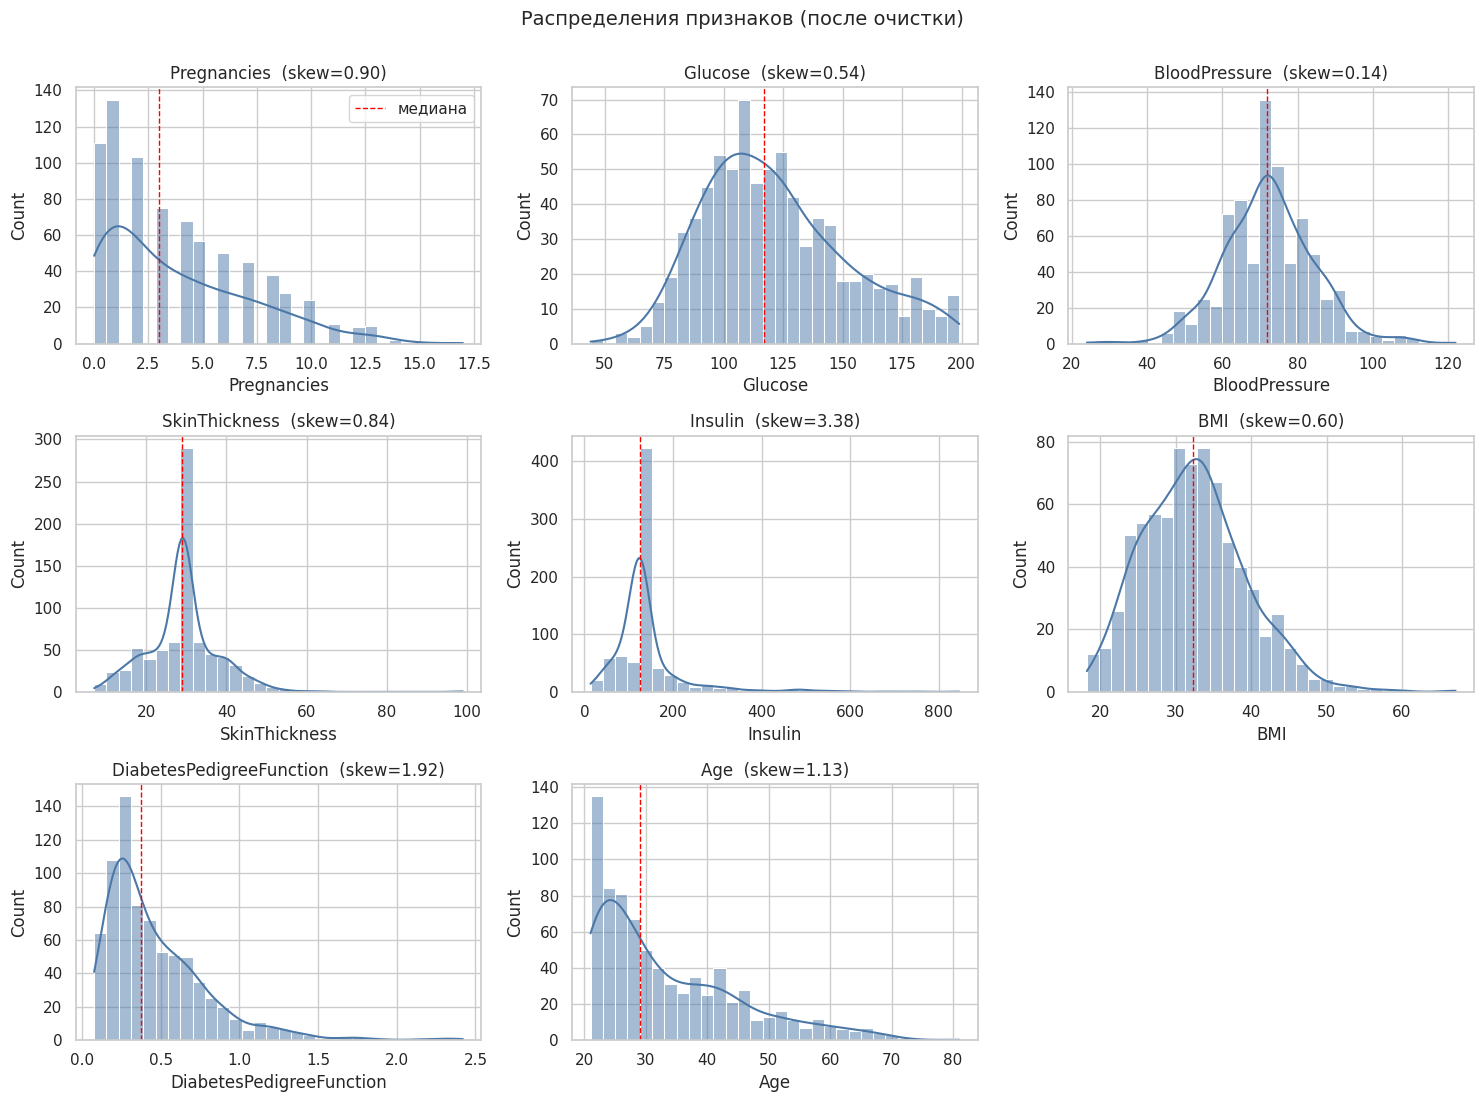

In [13]:
num_cols = [c for c in df_raw.columns if c != TARGET]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="#4C78A8")
    ax.axvline(df[col].median(), color="red", ls="--", lw=1, label="медиана")
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
axes.ravel()[-1].axis("off")
axes.ravel()[0].legend()
plt.suptitle("Распределения признаков (после очистки)", y=1.00, fontsize=14)
plt.tight_layout(); plt.show()

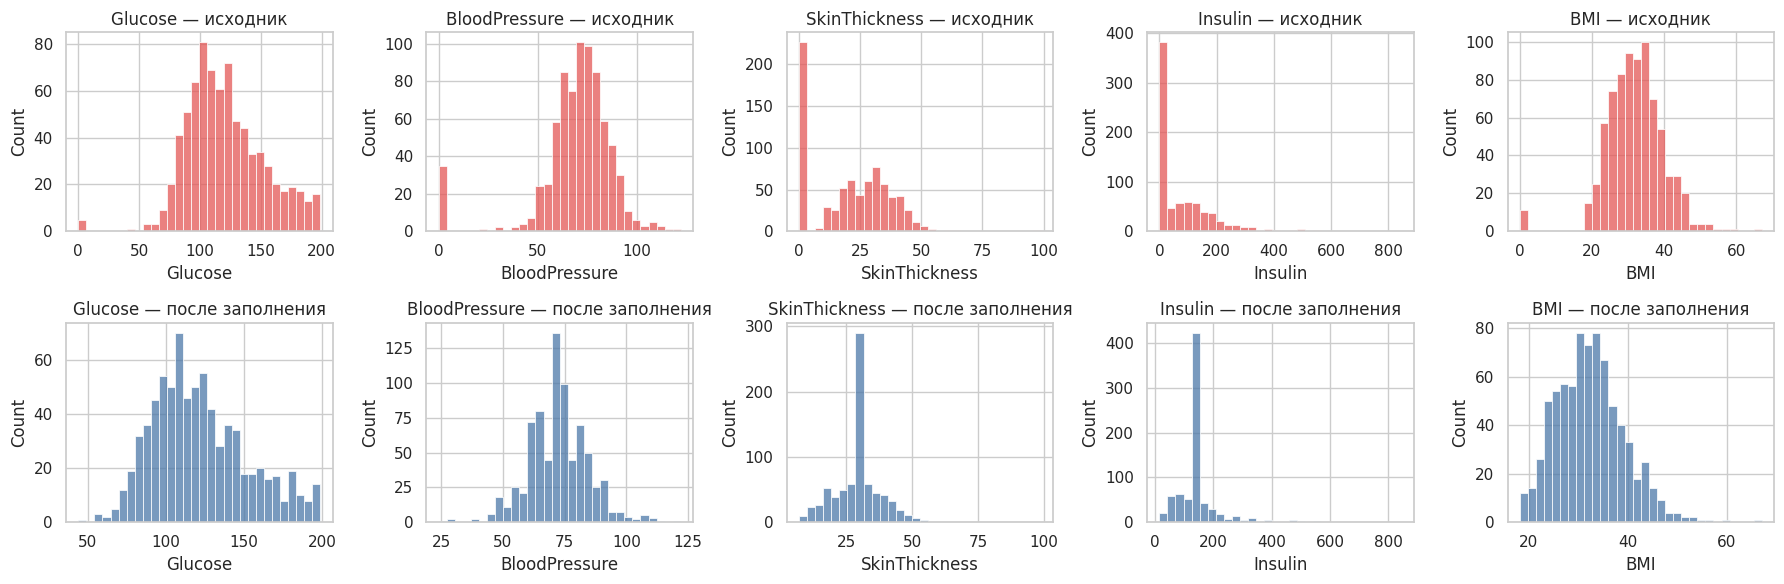

In [14]:
# Сравнение «до / после» для признаков со скрытыми пропусками
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for j, col in enumerate(ZERO_AS_NA):
    sns.histplot(df_raw[col], bins=30, ax=axes[0, j], color="#E45756")
    axes[0, j].set_title(f"{col} — исходник")
    sns.histplot(df[col], bins=30, ax=axes[1, j], color="#4C78A8")
    axes[1, j].set_title(f"{col} — после заполнения")
plt.tight_layout(); plt.show()

In [15]:
skew_tbl = pd.DataFrame({
    "skew": df[num_cols].skew().round(2),
    "kurtosis": df[num_cols].kurt().round(2),
})
skew_tbl["форма"] = np.where(skew_tbl["skew"].abs() > 1, "сильно скошено",
                     np.where(skew_tbl["skew"].abs() > 0.5, "умеренно скошено", "≈ симметрично"))
skew_tbl.sort_values("skew", ascending=False)

,skew,kurtosis,форма
Insulin,3.38,16.23,сильно скошено
DiabetesPedigreeFunction,1.92,5.59,сильно скошено
Age,1.13,0.64,сильно скошено
Pregnancies,0.90,0.16,умеренно скошено
SkinThickness,0.84,5.43,умеренно скошено
BMI,0.60,0.92,умеренно скошено
Glucose,0.54,-0.26,умеренно скошено
BloodPressure,0.14,1.10,≈ симметрично


**Наблюдения.**
- В исходнике у `Glucose`, `BloodPressure`, `BMI` виден «хвостик» около нуля, у `Insulin` и `SkinThickness` — огромный столбик в нуле: это артефакт кодирования пропусков.
- После заполнения у `Insulin`, `SkinThickness`, `BloodPressure` и `BMI` появляется острый пик на медиане — побочный эффект медианной импутации (занижает дисперсию).
- Сильно скошены вправо: `Insulin`, `DiabetesPedigreeFunction`, `Age`; умеренно — `Pregnancies`, `SkinThickness`, `BMI`, `Glucose`.

## 7. Boxplot приоритетных признаков, выбросы и аномалии
**Приоритетные признаки** (выбраны по доле скрытых пропусков и клинической значимости):
`Insulin`, `SkinThickness`, `BloodPressure`, `BMI`, `Glucose`.

Сначала — нарушения заданных правил диапазона (по исходнику), затем статистические выбросы по IQR (по измеренным значениям, без пропусков) и визуализация.

In [16]:
RULES = {
    "Pregnancies": (0, 20), "Glucose": (40, 500), "BloodPressure": (40, 140),
    "SkinThickness": (5, 100), "Insulin": (10, 900), "BMI": (12, 70),
    "DiabetesPedigreeFunction": (0.0001, 5), "Age": (18, 120),
}

range_tbl = pd.DataFrame({
    col: {"границы": f"{lo}–{hi}",
          "вне диапазона": int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum()),
          "из них нули": int((df_raw[col] == 0).sum() if col in ZERO_AS_NA else 0)}
    for col, (lo, hi) in RULES.items()
}).T
range_tbl

,границы,вне диапазона,из них нули
Pregnancies,0–20,0,0
Glucose,40–500,5,5
BloodPressure,40–140,39,35
SkinThickness,5–100,227,227
Insulin,10–900,374,374
BMI,12–70,11,11
DiabetesPedigreeFunction,0.0001–5,0,0
Age,18–120,0,0


In [17]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), round(lo, 2), round(hi, 2)

# Важно: IQR считаем по РЕАЛЬНО ИЗМЕРЕННЫМ значениям (нули = пропуски исключены).
# После медианной импутации квартили схлопываются, и «выбросами» становятся сотни честных значений.
measured = df_raw.copy()
measured[ZERO_AS_NA] = measured[ZERO_AS_NA].replace(0, np.nan)

iqr_tbl = pd.DataFrame(
    {col: iqr_outliers(measured[col].dropna()) for col in num_cols},
    index=["выбросов IQR", "нижняя граница", "верхняя граница"]).T
iqr_tbl["измерено значений"] = measured[num_cols].notna().sum()
iqr_tbl["доля, %"] = (iqr_tbl["выбросов IQR"] / iqr_tbl["измерено значений"] * 100).round(1)
iqr_tbl

,выбросов IQR,нижняя граница,верхняя граница,измерено значений,"доля, %"
Pregnancies,4.0,-6.50,13.50,768,0.5
Glucose,0.0,36.00,204.00,763,0.0
BloodPressure,14.0,40.00,104.00,733,1.9
SkinThickness,3.0,1.00,57.00,541,0.6
Insulin,24.0,-94.38,360.62,394,6.1
BMI,8.0,13.85,50.25,757,1.1
DiabetesPedigreeFunction,29.0,-0.33,1.20,768,3.8
Age,9.0,-1.50,66.50,768,1.2


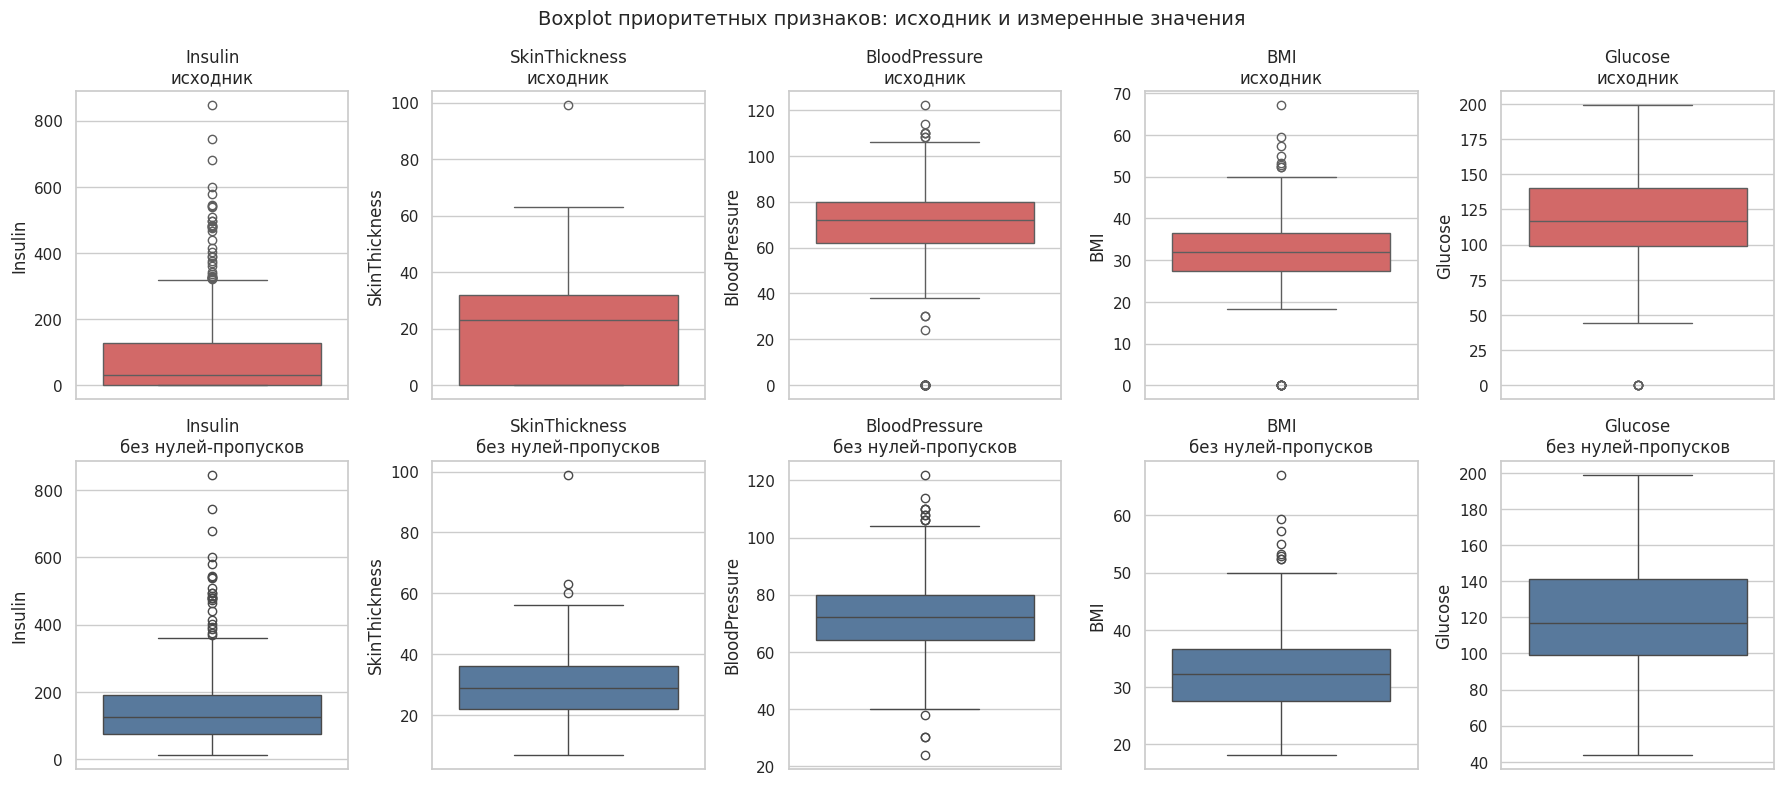

In [18]:
PRIORITY = ["Insulin", "SkinThickness", "BloodPressure", "BMI", "Glucose"]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for j, col in enumerate(PRIORITY):
    sns.boxplot(y=df_raw[col], ax=axes[0, j], color="#E45756")
    axes[0, j].set_title(f"{col}\nисходник")
    sns.boxplot(y=measured[col].dropna(), ax=axes[1, j], color="#4C78A8")
    axes[1, j].set_title(f"{col}\nбез нулей-пропусков")
plt.suptitle("Boxplot приоритетных признаков: исходник и измеренные значения", fontsize=14)
plt.tight_layout(); plt.show()

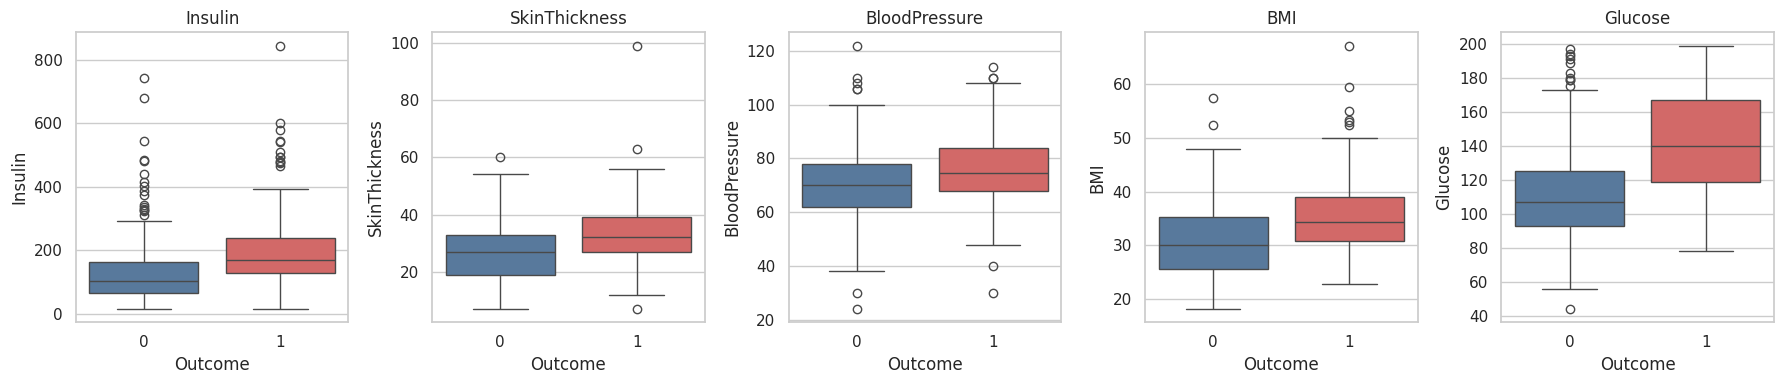

In [19]:
# Boxplot по классам: различается ли поведение выбросов в группах
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, PRIORITY):
    sns.boxplot(data=measured, x=TARGET, y=col, hue=TARGET, ax=ax, palette=["#4C78A8", "#E45756"], legend=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [20]:
# Конкретные «редкие» значения: смотрим, правдоподобны ли
print("Insulin > 500:              ", (measured["Insulin"] > 500).sum(), "| макс =", measured["Insulin"].max())
print("SkinThickness >= 60:        ", (df["SkinThickness"] >= 60).sum(), "| макс =", df["SkinThickness"].max())
print("BMI > 55:                   ", (df["BMI"] > 55).sum(), "| макс =", df["BMI"].max())
print("BloodPressure > 110 или < 45:", ((df["BloodPressure"] > 110) | (df["BloodPressure"] < 45)).sum())
print("Pregnancies >= 14:          ", (df["Pregnancies"] >= 14).sum(), "| макс =", df["Pregnancies"].max())
df.loc[(df["SkinThickness"] >= 60) | (df["BMI"] > 55) | (df["Insulin"] > 600),
       ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age", TARGET]]

Insulin > 500:               9 | макс = 846.0
SkinThickness >= 60:         3 | макс = 99.0
BMI > 55:                    3 | макс = 67.1
BloodPressure > 110 или < 45: 11
Pregnancies >= 14:           4 | макс = 17


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
13,1,189.0,60.0,23.0,846.0,30.1,59,1
57,0,100.0,88.0,60.0,110.0,46.8,31,0
177,0,129.0,110.0,46.0,130.0,67.1,26,1
228,4,197.0,70.0,39.0,744.0,36.7,31,0
247,0,165.0,90.0,33.0,680.0,52.3,23,0
445,0,180.0,78.0,63.0,14.0,59.4,25,1
579,2,197.0,70.0,99.0,125.0,34.7,62,1
673,3,123.0,100.0,35.0,240.0,57.3,22,0


**Оценка результата.**
- **Аномалии (ошибки данных):** нули в `Glucose` (5), `BloodPressure` (35), `BMI` (11), `SkinThickness` (227), `Insulin` (374) нарушают правила диапазона — в верхней строке boxplot они тянут нижние «усы» к нулю. На измеренных значениях (нижняя строка) нулей нет.
- **Статистические выбросы по IQR (измеренные значения):** `Insulin` — 24 (6.1%), длинный правый хвост до 846; `BloodPressure` — 14 (4 низких: 24, 30, 30, 38 и 10 высоких: 106–122); `BMI` — 8 (до 67.1); `SkinThickness` — 3 (в т. ч. 99 мм); `Glucose` — 0; `DiabetesPedigreeFunction` — 29 (3.8%).
- **Реально редкое, но допустимое:** высокий инсулин (до 846), BMI 52–67 и SkinThickness = 99 (запись 579) находятся в допустимых диапазонах и клинически возможны — такие значения и остальные статистические выбросы остаются в данных.
- **Нарушение допустимого диапазона:** давление < 40 (4 значения: 24, 30, 30, 38; правило 40–140) признано ошибкой и обработано ниже.
- Если считать IQR уже *после* медианной импутации, у `Insulin` «выбросами» станут 346 строк (45%) — это артефакт схлопнувшегося размаха, а не реальные аномалии.

### Обработка ошибочных значений
Значения `BloodPressure` ниже допустимой границы (< 40) заменяются на NaN и заполняются медианой измеренных значений — так же, как в п. 2.3.

In [21]:
# Обработка ошибочных значений: BloodPressure вне допустимых границ (после замены нулей)
bp_lo, bp_hi = RULES["BloodPressure"]
mask = (df["BloodPressure"] < bp_lo) | (df["BloodPressure"] > bp_hi)
print(f"BloodPressure: ошибочных значений {int(mask.sum())}, было {sorted(df.loc[mask, 'BloodPressure'].tolist())} -> медиана {medians['BloodPressure']}")
df.loc[mask, "BloodPressure"] = medians["BloodPressure"]

violations = {c: int(((df[c] < lo) | (df[c] > hi)).sum()) for c, (lo, hi) in RULES.items()}
print("\nНарушений правил диапазона после обработки:", violations)
print("NaN в таблице:", int(df.isna().sum().sum()))

BloodPressure: ошибочных значений 4, было [24.0, 30.0, 30.0, 38.0] -> медиана 72.0

Нарушений правил диапазона после обработки: {'Pregnancies': 0, 'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0, 'DiabetesPedigreeFunction': 0, 'Age': 0}
NaN в таблице: 0


## 8. Профиль качества исходной таблицы
Формат: показатель, число нарушений, база, доля. Расчёт — для **исходных 768 строк до исправлений**. Нарушения пересекаются, поэтому проценты нельзя складывать в общую долю плохих строк.

In [22]:
n = len(df_raw)
rows = []

rows.append(["Формальные пропуски (NaN), все поля", int(df_raw.isna().sum().sum()), f"{n*df_raw.shape[1]} ячеек", None])
for col in ZERO_AS_NA:
    rows.append([f"{col}: скрытый пропуск (0)", int((df_raw[col] == 0).sum()), f"{n} строк", None])
for col, (lo, hi) in RULES.items():
    k = int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())
    if col in ZERO_AS_NA:
        base = df_raw[col][df_raw[col] != 0]
        k_nz = int(((base < lo) | (base > hi)).sum())
        rows.append([f"{col}: вне {lo}–{hi} (без учёта нулей)", k_nz, f"{len(base)} ненулевых", None])
    else:
        rows.append([f"{col}: вне {lo}–{hi}", k, f"{n} строк", None])
for col in num_cols:
    k, _, _ = iqr_outliers(df_raw[col][df_raw[col] != 0] if col in ZERO_AS_NA else df_raw[col])
    base = (df_raw[col] != 0).sum() if col in ZERO_AS_NA else n
    rows.append([f"{col}: статистический выброс (IQR)", k, f"{base} значений", None])
rows.append(["Полные повторы сверх первой строки", int(df_raw.duplicated().sum()), f"{n} строк", None])
rows.append(["Повторы по признакам (без Outcome)", int(df_raw.duplicated(subset=feature_cols).sum()), f"{n} строк", None])
rows.append(["Константные столбцы", int((df_raw.nunique() == 1).sum()), f"{df_raw.shape[1]} столбцов", None])
rows.append(["Строк с ≥1 скрытым пропуском", int(miss_mask.any(axis=1).sum()), f"{n} строк", None])

profile = pd.DataFrame(rows, columns=["Проверка", "Нарушения", "База", "Доля"])
profile["Доля"] = profile.apply(lambda r: f"{r['Нарушения'] / int(r['База'].split()[0]) * 100:.1f}%", axis=1)
profile.to_csv("quality_profile.csv", index=False)
profile

,Проверка,Нарушения,База,Доля
0,"Формальные пропуски (NaN), все поля",0,6912 ячеек,0.0%
1,Glucose: скрытый пропуск (0),5,768 строк,0.7%
2,BloodPressure: скрытый пропуск (0),35,768 строк,4.6%
3,SkinThickness: скрытый пропуск (0),227,768 строк,29.6%
4,Insulin: скрытый пропуск (0),374,768 строк,48.7%
5,BMI: скрытый пропуск (0),11,768 строк,1.4%
6,Pregnancies: вне 0–20,0,768 строк,0.0%
7,Glucose: вне 40–500 (без учёта нулей),0,763 ненулевых,0.0%
8,BloodPressure: вне 40–140 (без учёта нулей),4,733 ненулевых,0.5%
9,SkinThickness: вне 5–100 (без учёта нулей),0,541 ненулевых,0.0%


In [23]:
# Итог: размеры таблицы до и после очистки
print(f"До:    {df_raw.shape}  | NaN: {int(df_raw.isna().sum().sum())} | скрытых пропусков: {int(miss_mask.sum().sum())}")
print(f"После: {df.shape}  | NaN: {int(df.isna().sum().sum())}")
df.to_csv("diabetes_clean.csv", index=False)
print("Сохранено: diabetes_clean.csv, quality_profile.csv")

До:    (768, 9)  | NaN: 0 | скрытых пропусков: 652
После: (768, 11)  | NaN: 0
Сохранено: diabetes_clean.csv, quality_profile.csv


## 9. Выводы

**Общее.** Набор небольшой (768 × 9), типы корректные, формальных пропусков (`NaN`), дубликатов и константных признаков **нет**. Однако формальная «чистота» обманчива: главная проблема качества — **скрытые пропуски, закодированные нулями**.

**Выявленные проблемы и их обработка**

| Проблема | Масштаб | Что сделано |
|---|---|---|
| Скрытые пропуски `Insulin` и `SkinThickness` (нули) | 48.7% и 29.6% строк; 49% строк имеют ≥1 пропуск, 234 строки — 2+ | Нули → NaN; строки не удалялись; заполнение медианой; добавлены флаги `Insulin_was_missing`, `SkinThickness_was_missing` |
| Нули в `BloodPressure`, `BMI`, `Glucose` | 35 / 11 / 5 значений (4.6% / 1.4% / 0.7%) | Нули → NaN → медиана |
| `BloodPressure` < 40 (вне допустимого диапазона 40–140) | 4 значения | Замена на NaN → медиана |

**Характеристики данных.**
- Баланс классов: 65.1% / 34.9% (500 и 268 пациенток), дисбаланс умеренный.
- Сильно скошены вправо `Insulin` (skew 3.4), `DiabetesPedigreeFunction` (1.9), `Age` (1.1).
- Статистические выбросы по IQR (после обработки: `Insulin` — 24, `BloodPressure` — 10 (ещё 4 значения ниже 40 заменены, см. выше), `BMI` — 8, `SkinThickness` — 3, в т. ч. значение 99) — редкие, но допустимые значения, оставлены в данных.

**Итог.** После обработки таблица (768 строк × 11 столбцов) не содержит пропусков, значений вне допустимых диапазонов, дубликатов и константных столбцов и пригодна для решения задачи классификации диабета.

**Артефакты:** `diabetes_clean.csv` (очищенная таблица +2 флага), `quality_profile.csv` (профиль качества)